# Analise Exploratória do dataset **orders_interim**
Meu objetivo é analisar se as alterações de limpeza feita estão coerentes e validar informações.


## Configurações iniciais

In [17]:
import sys
from pathlib import Path

PROJECT_FOLDER = Path.cwd().parents[1]
sys.path.append(str(PROJECT_FOLDER))

from src.utils.functions import get_path_config

In [18]:

import pandas as pd

Depois de importar as bibliotecas necessárias, vamos organizar os caminhos dos arquivos.

In [19]:
path_config = get_path_config()

interim_dir = PROJECT_FOLDER / path_config["paths"]["data_interim"]
order_interim_path = interim_dir / "orders_interim.parquet"


orders = pd.read_parquet(order_interim_path)

## Visão geral básica

In [20]:
orders.shape

(99441, 8)

In [21]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [22]:
orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03


In [23]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  string        
 1   customer_id                    99441 non-null  string        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(1), string(2)
memory usage: 6.1+ MB


## Duplicatas

Por regra de negócio, aqui a coluna **order_id** não pode ter duplicatas, vamos conferir se tem.

In [24]:
total_orders = len(orders)
unique_orders = orders["order_id"].nunique()
duplicated_orders = total_orders - unique_orders

print(
    f"Total de linhas: {total_orders}\n"
    f"Order_id distintos: {unique_orders}\n"
    f"Linhas duplicadas em order_id: {duplicated_orders}"
)

Total de linhas: 99441
Order_id distintos: 99441
Linhas duplicadas em order_id: 0


Como podemos ver, não tem nenhuma linha duplicada em **order_id**.

## Valores Faltantes (N/A)

Vamos chegar a porcentagem % dos valores nulos por colunas.

In [25]:
orders.isna().mean()

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
dtype: float64

Nesse quesito, os valores faltantes das colunas **order_approved_at** podem representar que o pedido não aprovado. E as outras colunas **order_delivered_carrier_date** e **order_delivered_customer_date** podem representar que alguns pedidos não foram entregues.

## Verificar coerência entre datas e `order_status`

Há pedidos entregues em que a data de entrega ao cliente é anterior à data de compra?

In [26]:
filter_order_delivered = (orders["order_status"] == "delivered")
filter_date_purchase = (
    orders["order_delivered_customer_date"] <
    orders["order_purchase_timestamp"]
)

orders_delivered = orders.loc[filter_order_delivered]

total_orders_delivered = orders_delivered.shape[0]

total_date_purchase = orders_delivered.loc[filter_date_purchase].shape[0]

print(f"De um total de {total_orders_delivered} pedidos entregues, {total_date_purchase} estão com datas incoerentes")


De um total de 96478 pedidos entregues, 0 estão com datas incoerentes


*Não encontrei nenhum pedido **delivered** com data de entrega anterior à data de compra (0 de 96.478).*

**Há pedidos entregues em que a data de entrega ao cliente é anterior à data de entrega para a transportadora?**

In [27]:
filter_date_delivered_carrier = (
    orders["order_delivered_customer_date"] < 
    orders["order_delivered_carrier_date"]
)

total_date_carrier = orders_delivered.loc[filter_date_delivered_carrier].shape[0]

print(f"De um total de {total_orders_delivered} pedidos entregues, {total_date_carrier} estão com datas incoerentes")

De um total de 96478 pedidos entregues, 23 estão com datas incoerentes


*Existem 23 pedidos **delivered** em que a entrega ao cliente ocorre antes da entrega para a transportadora, indicando possíveis erros pontuais de registro.*

**Há pedidos entregues em que a data de entrega ao cliente é anterior à data de aprovação do pedido?**

In [28]:
filter_date_purchase = (
    orders["order_approved_at"] >
    orders["order_delivered_customer_date"]
)

total_date_approved = orders_delivered.loc[filter_date_purchase].shape[0]

print(f"De um total de {total_orders_delivered} pedidos entregues, {total_date_approved} estão com datas incoerentes")


De um total de 96478 pedidos entregues, 61 estão com datas incoerentes


*Foram identificados 61 pedidos **delivered** com data de entrega anterior à aprovação do pedido, o que sugere inconsistências no registro das datas.*

**Entre os pedidos cancelados, quantos possuem data de entrega ao cliente preenchida?**

In [29]:
filter_order_canceled = (orders["order_status"] == "canceled")
filter_date_delivered = orders["order_delivered_customer_date"].notna()

orders_canceled = orders.loc[filter_order_canceled]

total_orders_canceled = orders_canceled.shape[0]

total_date_delivered = orders_canceled.loc[filter_date_delivered].shape[0]

print(f"De um total de {total_orders_canceled} pedidos cancelados, {total_date_delivered} estão com datas incoerentes")


De um total de 625 pedidos cancelados, 6 estão com datas incoerentes


*Entre os pedidos **canceled**, 6 ainda possuem data de entrega ao cliente registrada, o que é incoerente com o status de cancelado.*

## Análise gráfica da distribuição de `order_status`

In [30]:
import matplotlib.pyplot as plt

Nesta seção, quero visualizar a distribuição dos diferentes valores de order_status para entender quais status são mais frequentes e se existe algum grupo muito raro.

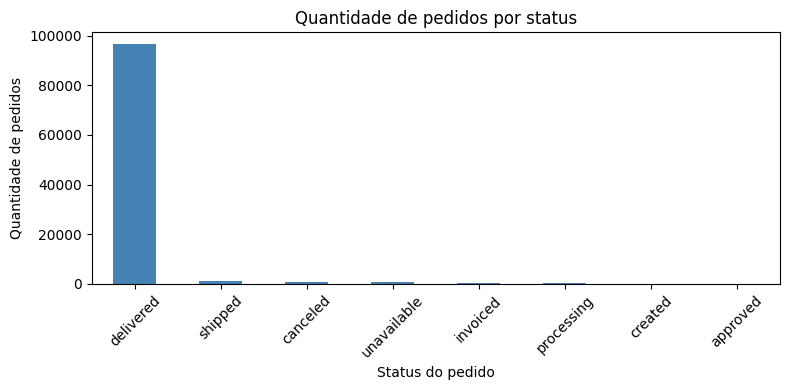

In [31]:
orders["order_status"].value_counts().plot(
    kind='bar',
    figsize=(8, 4),
    color='steelblue'
)

plt.title("Quantidade de pedidos por status")
plt.xlabel("Status do pedido")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vamos analisar agoraa questão temporal do dados

C:\Users\josei\AppData\Local\Temp\ipykernel_12968\673261693.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  orders.resample("Y", on="order_purchase_timestamp")["order_id"]


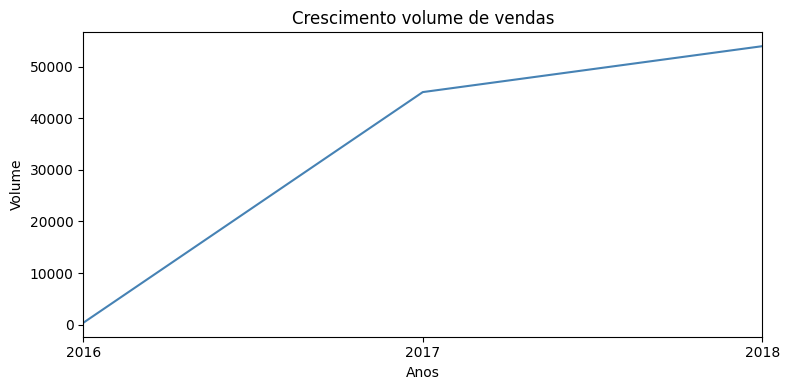

In [32]:
annual_orders = (
    orders.resample("Y", on="order_purchase_timestamp")["order_id"]
    .count()
)

annual_orders.plot(
    kind="line",
    figsize=(8, 4),
    color="steelblue"
)

plt.title("Crescimento volume de vendas")
plt.xlabel("Anos")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()



Podemos perceber que o volume de vendas teve durante um ano, com a maior significativa entre os anos de 2016 e 2017.

## CONCLUSÃO DA EDA